In [1]:
# import qiskit_aer

# from ewfs.setting import SETTING_PAIRS
# from ewfs.experiment import run_experiment
# from qiskit_ibm_runtime.fake_provider import FakeFez

# backend = qiskit_aer.Aer.get_backend("aer_simulator")
# backend = FakeFez()

# run_experiment(
#     shots=10_000,
#     num_trials=1,
#     charlie_sizes=range(1, 2),
#     debbie_sizes=[0],
#     strategy="majority_vote",
#     friend_state="ghz",
#     flag_size=6,
#     backend=backend,
#     settings=SETTING_PAIRS,
#     save=True,
# )

In [2]:
# from ewfs.setting import SETTING_PAIRS
# from ewfs.experiment import run_experiment

# from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#   token="htVYX3nZDI5I1fSkYQw8Y0rddMrBi1eElvW8EHhy5D4q",
#   name="farrokh",
#   channel="ibm_quantum_platform",
#   overwrite=True
# )
# service = QiskitRuntimeService(name="farrokh")
# backend = service.backend("ibm_pittsburgh")


# run_experiment(
#     shots=10_000,
#     num_trials=1,
#     charlie_sizes=range(1, 2),
#     debbie_sizes=[0],
#     strategy="majority_vote",
#     friend_state="ghz",
#     flag_size=6,
#     backend=backend,
#     settings=SETTING_PAIRS,
#     save=True,
# )

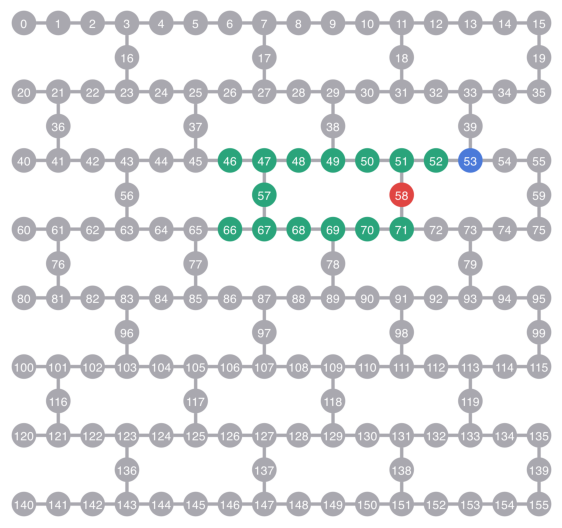

In [259]:
from ewfs.ghz import plot_ghz_fez
from qiskit_ibm_runtime.fake_provider import FakeFez

coupling_map = FakeFez().coupling_map

def remove_elements(source_list, elements_to_remove):
    return [item for item in source_list if item not in elements_to_remove]

layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [56, 58]

layout = [53, 52, 51, 50, 49, 48, 47, 46, 66, 67, 57, 68, 69, 70, 71, 58]

flags = [58]

# layout = [53, 52, 51, 58, 50]
# layout = [53, 52, 51, 50, 49]
# flags = []

start_qubit = layout[0]

plot_ghz_fez(coupling_map=coupling_map, data_qubits=remove_elements(layout, flags), flag_qubits=flags, start_qubit=start_qubit)

In [260]:
"""Extended Wigner's friend scenario (EWFS)" functionality."""

from qiskit import QuantumCircuit

from ewfs.observer import DEFAULT_ANGLES, DEFAULT_BETA
from ewfs.setting import PEEK, REVERSE_1, REVERSE_2

from qiskit_ibm_runtime.fake_provider import FakeFez
backend = FakeFez()
coupling_map = backend.coupling_map


class Friend:
    def __init__(self, size: int, qubits: list[int], label: str) -> None:
        """Initialize the friend.

        Attributes:
            size: The size of the friend's subsystem.
            qubits: The indices of the qubits in the friend's subsystem.
            label: The label of the friend.
        """
        self.size = size
        self.qubits = qubits
        self.label = label


class EWFS:
    def __init__(
        self,
        alice_setting: str,
        bob_setting: str,
        coupling_map: list,
        layout: list,
        flag_qubits: list,
        angles: dict[str, float] | None = None,
        beta: float | None = None,
    ) -> None:
        """Initialize the extended Wigner's friend scenario."""
        # Settings for Alice and Bob.
        self.alice_setting = alice_setting
        self.bob_setting = bob_setting

        self.coupling_map = coupling_map
        self.layout = layout
        self.flag_qubits = flag_qubits
        self.data_qubits = self._remove_elements(layout, flag_qubits)
        self.layout_dict = dict(zip(layout, range(len(layout))))
        print(self.layout_dict)

        self.alice = self.layout_dict[self.layout[1]] #hardcoded
        self.bob = self.layout_dict[self.layout[0]]

        self.charlie_qubits = [self.layout_dict[self.data_qubits[i]] for i in range(2, len(self.data_qubits))] # the first two qubits should always be the system qubits
        self.charlie_size = len(self.charlie_qubits)

        self.sys_size = 2
        self.meas_size = 2

        # Angles for Alice and Bob measurements.
        self.angles = angles or DEFAULT_ANGLES
        self.beta = beta or DEFAULT_BETA

    def circuit(self) -> QuantumCircuit:
        """Generate the circuit for extended Wigner's friend scenario."""
        # Initialize system qubits and entangle with Charlie
        qc = self._initialize_circuit()

        alice_creg, bob_creg, flag_creg = self._get_classical_registers()
        print('alice, bob, flag creg: ', (alice_creg, bob_creg, flag_creg))

        charlie = Friend(
            size=self.charlie_size, qubits=self.charlie_qubits, label="Charlie"
        )

        # qc.barrier()
        
        # Apply the setting for Alice/Charlie.
        self._apply_setting(
            qc=qc,
            observer=self.alice,
            setting=self.alice_setting,
            angle=self.angles[self.alice_setting],
            observer_creg=alice_creg,
            friend=charlie,
        )
        # Apply the setting for Bob.
        self._apply_setting(
            qc=qc,
            observer=self.bob,
            setting=self.bob_setting,
            angle=(self.beta - self.angles[self.bob_setting]),
            observer_creg=bob_creg,
            friend=None,
        )
       
        # Finally, measure the flag qubits
        flag_qubits = [self.layout_dict[flag] for flag in self.flag_qubits]
        print('flag_qubits: ', flag_qubits)
        qc.measure(flag_qubits, flag_creg)

        return qc

    def _get_directed_tree_edges(self):
        """
        Determines the set of directed edges for a tree by performing a BFS.

        This function simulates "pouring water" into a start_node and tracking its
        flow to neighboring nodes within a specified tree, creating a directed graph.

        Args:
            coupling_map: A graph object with a .neighbors(node) method.
            tree_nodes (list or set): A collection of nodes that form the tree
                                    within the coupling_map.
            start_node: The node where the traversal begins.

        Returns:
            set: A set of tuples, where each tuple (u, v) represents a
                directed edge from node u to node v.
        """
        from collections import deque

        coupling_map = self.coupling_map
        tree_nodes = self.data_qubits[1:]
        start_node = tree_nodes[0]

        # Use a set for efficient O(1) lookups
        tree_nodes_set = set(tree_nodes)
        
        # The queue holds nodes whose neighbors we need to visit
        queue = deque([start_node])
        
        # Keep track of nodes we've already visited to avoid cycles and redundant work
        visited = {start_node}
        
        # This will store our final result
        directed_edges = []

        while queue:
            # Get the next node to process from the front of the queue
            current_node = queue.popleft()

            # Check all its neighbors in the original graph
            for neighbor in coupling_map.neighbors(current_node):
                # The neighbor is valid if it's in our target tree AND we haven't visited it yet
                if neighbor in tree_nodes_set and neighbor not in visited:
                    # Mark it as visited so we don't process it again
                    visited.add(neighbor)
                    # Add it to the queue to process its own neighbors later
                    queue.append(neighbor)
                    # Add the directed edge from our current node to this new neighbor
                    directed_edges.append((current_node, neighbor))
                    
        return directed_edges
        
    def _ghz(self, qc):
        self.ghz_ops = self._get_directed_tree_edges()
        print('ghz_ops: ', self.ghz_ops)
        for op in self.ghz_ops:
            qc.cx(self.layout_dict[op[0]], self.layout_dict[op[1]])

    def _ghz_inverse(self, qc):
        # implement the inverse of the ghz operations
        ops_reverse = self.ghz_ops[::-1]

        for op in ops_reverse:
            qc.cx(self.layout_dict[op[0]], self.layout_dict[op[1]])

    def _flag_operations(self, qc):
        self.flag_ops = []
        for flag in self.flag_qubits:
            neighbors = self.coupling_map.neighbors(flag)
            for qubit in neighbors:
                qc.cx(self.layout_dict[qubit], self.layout_dict[flag])
                self.flag_ops.append((self.layout_dict[qubit], self.layout_dict[flag]))
        print('flag_ops: ', self.flag_ops)

    def _flag_operations_inverse(self, qc):
        # implement the inverse of the flag operations
        ops_reverse = self.flag_ops[::-1]

        for op in ops_reverse:
            qc.cx(op[0], op[1])
        
    def _remove_elements(self, source_list, elements_to_remove):
        return [item for item in source_list if item not in elements_to_remove]

    def _initialize_circuit(self) -> QuantumCircuit:
        """Initialize the classical measurement registers based on the strategy."""
        if self.alice_setting == PEEK:
            meas_size = self.charlie_size + 1
        else:
            meas_size = 2
        meas_size += len(self.flag_qubits)
        
        # measurement = ClassicalRegister(size, name="measurement")

        qc = QuantumCircuit(len(self.layout), meas_size)

        # first create entanglement between the system qubits
        
        self._prepare_bipartite_system(qc, self.alice, self.bob)

        # Perform the rotations for Alice and Bob based on their settings.
        self._ewfs_rotation(qc, self.alice, self.angles[PEEK])
        self._ewfs_rotation(qc, self.bob, self.beta - self.angles[PEEK])

        # then create the ghz state on the data qubits ({layout}\{flags} u {bob})
        self._ghz(qc)

        # now implement the check operations
        self._flag_operations(qc)
        
        return qc
        
    def _get_classical_registers(self) -> tuple:
        """Define the classical registers for the observers and the flag register."""
        if self.alice_setting is PEEK and self.bob_setting is not PEEK:
            alice_creg = list(range(self.charlie_size))
            bob_creg = [self.charlie_size]
        else:
            alice_creg, bob_creg = [0], [1]

        flag_creg = list(range(bob_creg[0] + 1, bob_creg[0] + 1 + len(self.flag_qubits)))

        return alice_creg, bob_creg, flag_creg
        

    def _prepare_bipartite_system(self, qc: QuantumCircuit, alice: int, bob: int) -> None:
        """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
        qc.x(alice)
        qc.x(bob)
        qc.h(alice)
        qc.cx(alice, bob)

    def _apply_setting(
        self,
        qc: QuantumCircuit,
        observer: int,
        setting: str,
        angle: float,
        observer_creg: list[int],
        friend: Friend | None,
    ):
        """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
        if setting is PEEK:
            self._apply_peek(qc, observer_creg, friend)
        elif setting in [REVERSE_1, REVERSE_2]:
            self._apply_reverse(qc, observer, observer_creg, friend, angle)

    def _apply_peek(self, qc: QuantumCircuit, observer_creg: list[int], friend: Friend) -> None:
        # Ask friend for the outcome.
        qc.measure(friend.qubits, observer_creg)

    def _apply_reverse(
        self,
        qc: QuantumCircuit,
        observer: int,
        observer_creg: list[int],
        friend: Friend | None,
        angle: float,
    ) -> None:
        
        if friend is not None:
            qc.barrier(observer, friend.qubits)
            # do the inverse of ghz() function
            self._flag_operations_inverse(qc)
            self._ghz_inverse(qc)

        # Apply the rotation based on the observer.
        if observer is self.alice:
            self._ewfs_rotation(qc, observer, self.angles[PEEK], invert=False)
        if observer is self.bob:
            self._ewfs_rotation(qc, observer, self.beta - self.angles[PEEK], invert=False)

        # Apply a rotation.
        self._ewfs_rotation(qc, observer, angle)

        qc.measure(observer, observer_creg)

    def _ewfs_rotation(self, qc: QuantumCircuit, observer: int, angle: float, invert: bool = True) -> None:
        """Apply an EWFS-specific rotation to a qubit."""
        if invert:
            qc.rz(-angle, observer)
            qc.h(observer)
        else:
            qc.h(observer)
            qc.rz(angle, observer)

{53: 0, 52: 1, 51: 2, 50: 3, 49: 4, 48: 5, 47: 6, 46: 7, 57: 8, 66: 9, 67: 10, 68: 11, 69: 12, 70: 13, 71: 14, 58: 15}
ghz_ops:  [(52, 51), (51, 50), (50, 49), (49, 48), (48, 47), (47, 46), (47, 57), (57, 67), (67, 66), (67, 68), (68, 69), (69, 70), (70, 71)]
flag_ops:  [(2, 15), (14, 15)]
alice, bob, flag creg:  ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], [13], [14])
flag_qubits:  [15]


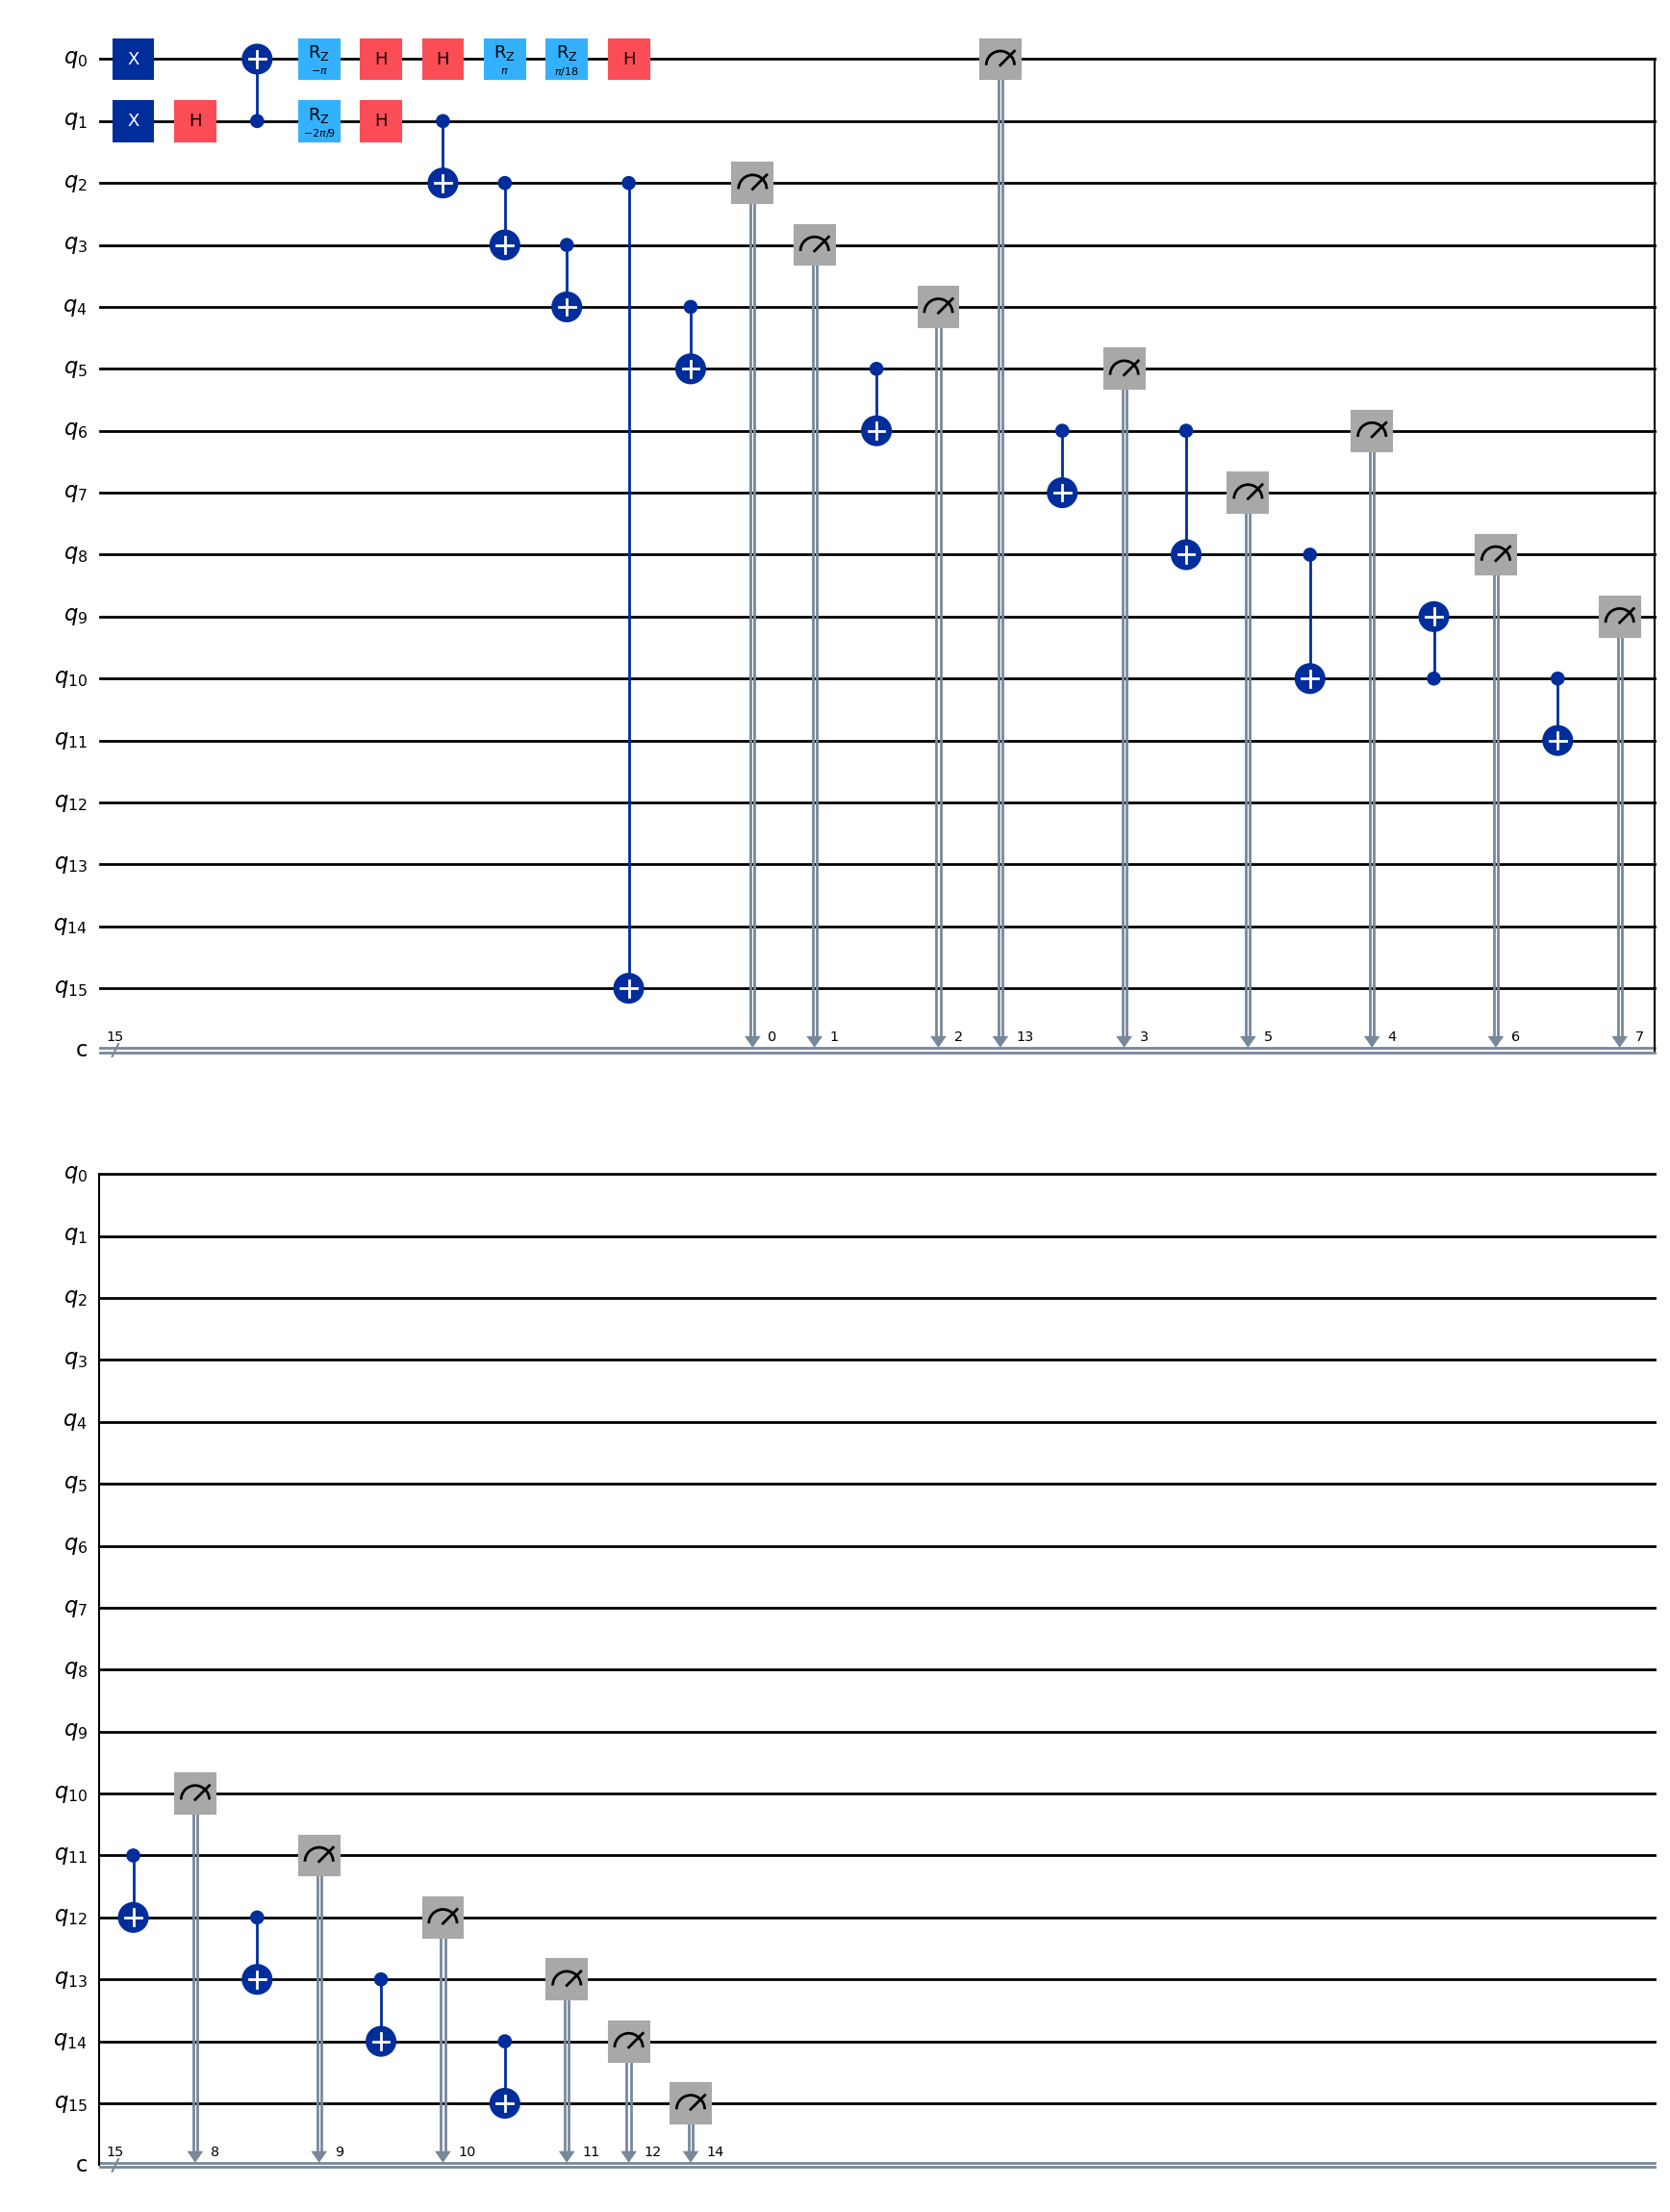

In [261]:
# layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

# flags = [56, 58]

layout = [53, 52, 51, 50, 49, 48, 47, 46, 57, 66, 67, 68, 69, 70, 71, 58]

flags = [58]

# layout = [53, 52, 51, 58, 50]
# # layout = [53, 52, 51, 50, 49]
# flags = []

ewfs = EWFS(
    alice_setting=PEEK,
    bob_setting=REVERSE_1,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags)
qc = ewfs.circuit()
qc.draw('mpl')

{53: 0, 52: 1, 51: 2, 58: 3, 50: 4}
flag_ops:  []
alice, bob, flag creg:  ([0, 1, 2], [3], [])
flag_qubits:  []


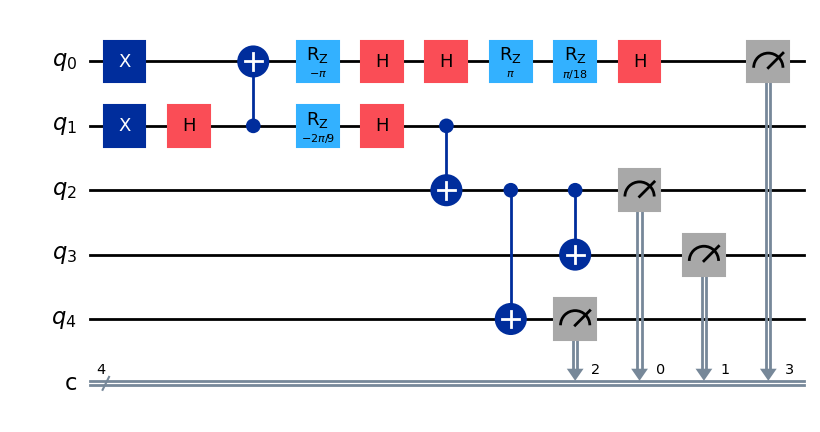

In [253]:
layout = [53, 52, 51, 50, 49]
layout = [53, 52, 51, 58, 50]
flags = []

ewfs = EWFS(
    alice_setting=PEEK,
    bob_setting=REVERSE_1,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags)
qc = ewfs.circuit()
qc.draw('mpl')

In [262]:
from qiskit_aer import Aer
from qiskit import transpile
from ewfs import decode_results, post_select_results


# layout = [53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 56, 63, 64, 65, 66, 67, 57, 68, 69, 70, 71, 58]

# flags = [56, 58]

layout = [53, 52, 51, 50, 49, 48, 47, 46, 57, 67, 68, 69, 70, 71, 58]

flags = [58]


backend = Aer.get_backend("aer_simulator")
settings = [(PEEK, REVERSE_1), (PEEK, REVERSE_2), (REVERSE_2, REVERSE_1), (REVERSE_2, REVERSE_2)]

semi_brukner_circuits = [EWFS(
    alice_setting=s1,
    bob_setting=s2,
    coupling_map=coupling_map,
    layout=layout,
    flag_qubits=flags).circuit() for s1, s2 in settings]

transpiled_circuits = [transpile(circuit, backend, optimization_level=3) for circuit in semi_brukner_circuits]

settings_circuits = dict(zip(settings, transpiled_circuits))

from qiskit_ibm_runtime import SamplerV2

sampler = SamplerV2(backend)

shots = 10_000
res = sampler.run(transpiled_circuits, shots=shots).result()

results = {}
i=0

for pub in res:
    print(pub.data.c.get_counts())
    probabilities = {key: value / shots for key, value in pub.data.c.get_counts().items()}
    results[settings[i]] = probabilities
    i+=1

post_selected_results = post_select_results(results, len(flags))
post_selected_results

{53: 0, 52: 1, 51: 2, 50: 3, 49: 4, 48: 5, 47: 6, 46: 7, 57: 8, 67: 9, 68: 10, 69: 11, 70: 12, 71: 13, 58: 14}
ghz_ops:  [(52, 51), (51, 50), (50, 49), (49, 48), (48, 47), (47, 57), (47, 46), (57, 67), (67, 68), (68, 69), (69, 70), (70, 71)]
flag_ops:  [(13, 14), (2, 14)]
alice, bob, flag creg:  ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12], [13])
flag_qubits:  [14]
{53: 0, 52: 1, 51: 2, 50: 3, 49: 4, 48: 5, 47: 6, 46: 7, 57: 8, 67: 9, 68: 10, 69: 11, 70: 12, 71: 13, 58: 14}
ghz_ops:  [(52, 51), (51, 50), (50, 49), (49, 48), (48, 47), (47, 57), (47, 46), (57, 67), (67, 68), (68, 69), (69, 70), (70, 71)]
flag_ops:  [(2, 14), (13, 14)]
alice, bob, flag creg:  ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12], [13])
flag_qubits:  [14]
{53: 0, 52: 1, 51: 2, 50: 3, 49: 4, 48: 5, 47: 6, 46: 7, 57: 8, 67: 9, 68: 10, 69: 11, 70: 12, 71: 13, 58: 14}
ghz_ops:  [(52, 51), (51, 50), (50, 49), (49, 48), (48, 47), (47, 46), (47, 57), (57, 67), (67, 68), (68, 69), (69, 70), (70, 71)]
flag_ops:  [(2, 14),

{('peek', 'reverse_1'): {'1000000000000': 0.4092,
  '0111111111111': 0.4148,
  '1111111111111': 0.0926,
  '0000000000000': 0.0834},
 ('peek', 'reverse_2'): {'0000000000000': 0.4144,
  '1111111111111': 0.4096,
  '0111111111111': 0.0851,
  '1000000000000': 0.0909},
 ('reverse_2', 'reverse_1'): {'01': 0.4476,
  '10': 0.43,
  '11': 0.0596,
  '00': 0.0628},
 ('reverse_2', 'reverse_2'): {'01': 0.4519,
  '10': 0.4317,
  '00': 0.058,
  '11': 0.0584}}

In [255]:
from ewfs import decode_results, post_select_results

charlie_size = len(layout) - len(flags) - 2
debbie_size = 0
flag_size = len(flags)

post_selected_results = post_select_results(results, flag_size)
dec_res = decode_results(post_selected_results, charlie_size=charlie_size)
dec_res

{('peek', 'reverse_1'): {'01': 0.4139, '00': 0.0886},
 ('peek', 'reverse_2'): {'01': 0.0926, '00': 0.4126},
 ('reverse_2', 'reverse_1'): {'10': 0.4394,
  '01': 0.4443,
  '00': 0.0573,
  '11': 0.059},
 ('reverse_2', 'reverse_2'): {'10': 0.4314,
  '01': 0.451,
  '11': 0.0607,
  '00': 0.0569}}

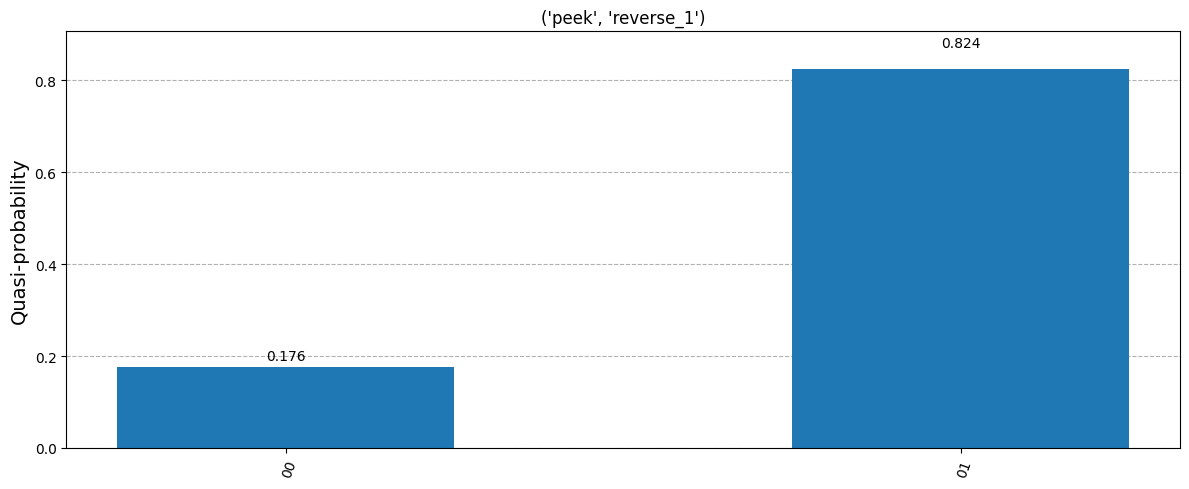

In [194]:
from qiskit.visualization import plot_distribution
i=0
setting, probs = settings[i], dec_res[settings[i]]
plot_distribution(probs, figsize=(12, 5), title=setting)


In [9]:
# layout = [53, 52, 51, 50, 49]

# flags = []

# ewfs = EWFS(
#     alice_setting=REVERSE_2,
#     bob_setting=REVERSE_1,
#     coupling_map=coupling_map,
#     layout=layout,
#     flag_qubits=flags)
# qc = ewfs.circuit()
# qc.draw('mpl')